# **WALKING & RUNNING CLASSIFICATION PROJECT**

## **PROBLEM STATEMENT**
 
### **Task 1:** Prepare a detailed data analysis report on the provided dataset.
### **Task 2:** Develop a predictive model to classify whether a person is running or walking using sensor data.

### **Dataset Overview:** 
### - This project focuses on training and evaluating multi-layer neural networks.
### - The dataset used is a subset of the original *Run or Walk* dataset.

### **Attributes in the Dataset:**
### The dataset consists of motion sensor readings while individuals engaged in daily activities. Key attributes include:
### - **Date & Time** - Timestamp of the recorded data.
### - **Username** - Identification of the user.
### - **Wrist** - Location of the sensor.
### - **Activity** - Label indicating whether the person was walking or running.
### - **Acceleration (x, y, z)** - Movement data in three dimensions.
### - **Gyroscope (x, y, z)** - Angular velocity data.

### **Model Performance Comparison:**
### - Multiple machine learning models are trained and evaluated.
### - The model with the best accuracy and F1-score is recommended for production.

### **Challenges & Solutions:**
### - The report highlights challenges faced during data processing and modeling.
### - The techniques used to overcome these challenges are explained with reasoning.



In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from imblearn.over_sampling import SMOTE
import joblib
import xgboost as xgb
from sklearn.decomposition import PCA

# **Loading the Dataset**

In [7]:
data=pd.read_csv(r"C:\\Users\\ASUS\\Desktop\\Datamites internship\\PRCP-1013-WalkRunClass\\PRCP-1013-WalkRunClass\\Data\\walkrun.csv")
data

,date,time,username,wrist,activity,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z
0,2017-6-30,13:51:15:847724020,viktor,0,0,0.2650,-0.7814,-0.0076,-0.0590,0.0325,-2.9296
1,2017-6-30,13:51:16:246945023,viktor,0,0,0.6722,-1.1233,-0.2344,-0.1757,0.0208,0.1269
2,2017-6-30,13:51:16:446233987,viktor,0,0,0.4399,-1.4817,0.0722,-0.9105,0.1063,-2.4367
3,2017-6-30,13:51:16:646117985,viktor,0,0,0.3031,-0.8125,0.0888,0.1199,-0.4099,-2.9336
4,2017-6-30,13:51:16:846738994,viktor,0,0,0.4814,-0.9312,0.0359,0.0527,0.4379,2.4922
...,...,...,...,...,...,...,...,...,...,...,...
88583,2017-7-9,20:9:15:317911028,viktor,0,0,0.3084,-0.8376,-0.1327,0.4823,2.0124,0.6048
88584,2017-7-9,20:9:15:517889022,viktor,0,0,0.4977,-1.0027,-0.4397,0.1022,-1.2565,-0.0761
88585,2017-7-9,20:9:15:717828989,viktor,0,0,0.4587,-1.1780,-0.2827,-1.4500,-0.2792,-1.2616
88586,2017-7-9,20:9:15:917932987,viktor,0,0,0.2590,-0.8582,-0.0759,-1.5165,0.4560,-1.7755


# **Basic Data Information**

In [9]:
display(data.info())
display(data.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88588 entries, 0 to 88587
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            88588 non-null  object 
 1   time            88588 non-null  object 
 2   username        88588 non-null  object 
 3   wrist           88588 non-null  int64  
 4   activity        88588 non-null  int64  
 5   acceleration_x  88588 non-null  float64
 6   acceleration_y  88588 non-null  float64
 7   acceleration_z  88588 non-null  float64
 8   gyro_x          88588 non-null  float64
 9   gyro_y          88588 non-null  float64
 10  gyro_z          88588 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 7.4+ MB


None

,date,time,username,wrist,activity,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z
0,2017-6-30,13:51:15:847724020,viktor,0,0,0.2650,-0.7814,-0.0076,-0.0590,0.0325,-2.9296
1,2017-6-30,13:51:16:246945023,viktor,0,0,0.6722,-1.1233,-0.2344,-0.1757,0.0208,0.1269
2,2017-6-30,13:51:16:446233987,viktor,0,0,0.4399,-1.4817,0.0722,-0.9105,0.1063,-2.4367
3,2017-6-30,13:51:16:646117985,viktor,0,0,0.3031,-0.8125,0.0888,0.1199,-0.4099,-2.9336
4,2017-6-30,13:51:16:846738994,viktor,0,0,0.4814,-0.9312,0.0359,0.0527,0.4379,2.4922


# **Checking for Missing Values**

In [12]:
missing_values = data.isnull().sum()
print("# Missing Values in Dataset #")
print(missing_values)

# Missing Values in Dataset #
date              0
time              0
username          0
wrist             0
activity          0
acceleration_x    0
acceleration_y    0
acceleration_z    0
gyro_x            0
gyro_y            0
gyro_z            0
dtype: int64


# **Data Preprocessing**

In [15]:
data = data.drop(columns=['date', 'time', 'username'])

# **Feature Engineering:**

In [18]:
data['acceleration_magnitude'] = np.sqrt(data['acceleration_x']**2 + data['acceleration_y']**2 + data['acceleration_z']**2)
data['gyro_magnitude'] = np.sqrt(data['gyro_x']**2 + data['gyro_y']**2 + data['gyro_z']**2)

In [20]:
# **Defining Features & Target Variable**
X = data.drop(columns=['activity'])
y = data['activity']

In [22]:
# **Handling Class Imbalance using SMOTE**
smote = SMOTE()
X, y = smote.fit_resample(X, y)

In [23]:
# **Feature Selection using PCA**
pca = PCA(n_components=5)
X = pca.fit_transform(X)

# **Additional Data Visualizations**

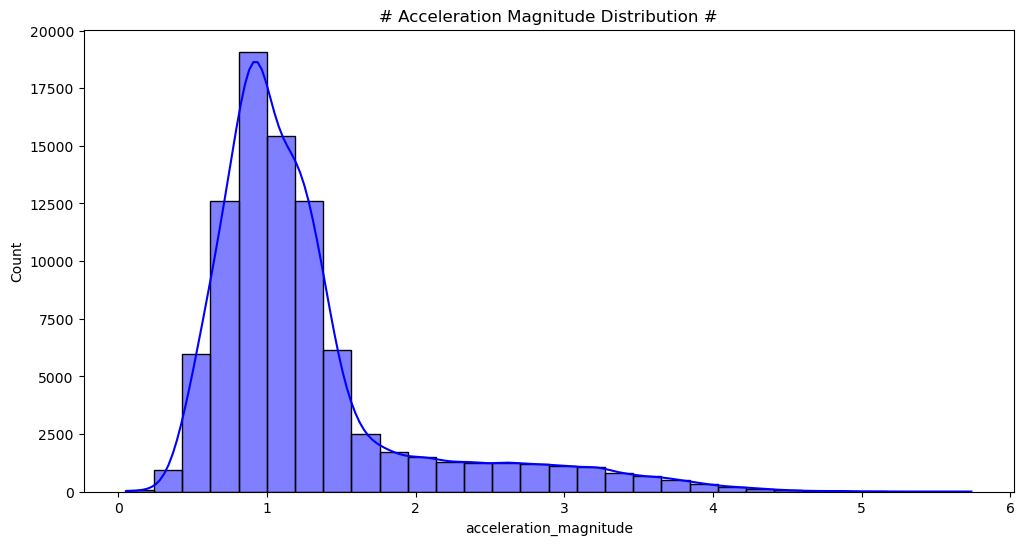

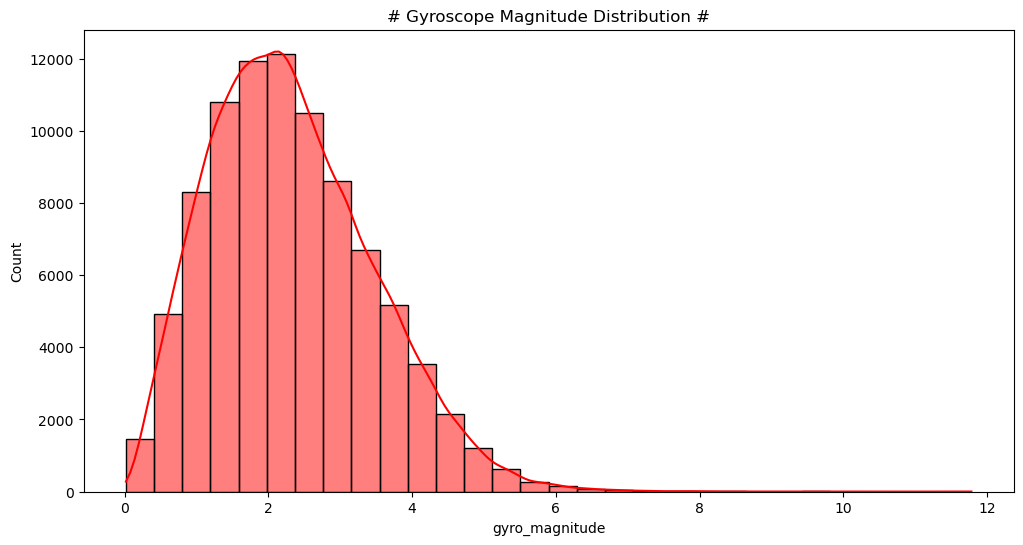

In [27]:
plt.figure(figsize=(12, 6))
sns.histplot(data['acceleration_magnitude'], bins=30, kde=True, color='blue')
plt.title("# Acceleration Magnitude Distribution #")
plt.show()

plt.figure(figsize=(12, 6))
sns.histplot(data['gyro_magnitude'], bins=30, kde=True, color='red')
plt.title("# Gyroscope Magnitude Distribution #")
plt.show()

# **Splitting the Data into Training and Testing Sets**

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [31]:
# **Applying MinMax Scaling**
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **Model Training & Evaluation**

In [35]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=15),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(128,64,32), max_iter=3000, solver='adam', learning_rate_init=0.001),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=300, learning_rate=0.05),
    "Support Vector Machine": SVC(kernel='rbf', C=2.0, gamma='scale'),
    "AdaBoost": AdaBoostClassifier(n_estimators=200),
    "XGBoost": xgb.XGBClassifier(n_estimators=300, learning_rate=0.05)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    results[name] = (acc, f1)
    print(f"*{name} Accuracy:* {acc:.4f}, F1-score: {f1:.4f}")
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))
    print("-"*50)

*Logistic Regression Accuracy:* 0.6750, F1-score: 0.6741
              precision    recall  f1-score   support

           0       0.66      0.73      0.69      8873
           1       0.70      0.62      0.66      8873

    accuracy                           0.68     17746
   macro avg       0.68      0.68      0.67     17746
weighted avg       0.68      0.68      0.67     17746

[[6455 2418]
 [3349 5524]]
--------------------------------------------------
*Random Forest Accuracy:* 0.9442, F1-score: 0.9442
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      8873
           1       0.97      0.92      0.94      8873

    accuracy                           0.94     17746
   macro avg       0.95      0.94      0.94     17746
weighted avg       0.95      0.94      0.94     17746

[[8610  263]
 [ 727 8146]]
--------------------------------------------------
*Neural Network Accuracy:* 0.9615, F1-score: 0.9615
              precision    rec

C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


*AdaBoost Accuracy:* 0.7723, F1-score: 0.7705
              precision    recall  f1-score   support

           0       0.73      0.86      0.79      8873
           1       0.83      0.68      0.75      8873

    accuracy                           0.77     17746
   macro avg       0.78      0.77      0.77     17746
weighted avg       0.78      0.77      0.77     17746

[[7656 1217]
 [2823 6050]]
--------------------------------------------------
*XGBoost Accuracy:* 0.9347, F1-score: 0.9347
              precision    recall  f1-score   support

           0       0.91      0.96      0.94      8873
           1       0.96      0.91      0.93      8873

    accuracy                           0.93     17746
   macro avg       0.94      0.93      0.93     17746
weighted avg       0.94      0.93      0.93     17746

[[8556  317]
 [ 841 8032]]
--------------------------------------------------


# **Model Training & Evaluation**

In [37]:
best_model = max(results, key=lambda k: results[k][0])
print(f"*Best Model:* {best_model} with Accuracy {results[best_model][0]:.4f}, F1-score {results[best_model][1]:.4f}")

*Best Model:* Neural Network with Accuracy 0.9615, F1-score 0.9615


In [38]:
# **Saving the Best Model**
joblib.dump(models[best_model], "best_model.pkl")
print("# Best model saved as best_model.pkl #")

# Best model saved as best_model.pkl #
